### [ 연속 영역 분할 3 : 색 채우기 (Flood Fill)] <hr>
- 지정한 시작점에서 출발하여 연결된 같은 영역을 새로운 색으로 채움
- 그림판의 페인트 통 기능과 같은 원리

In [2]:
import cv2
import numpy as np
import sys
import matplotlib.pyplot as plt
sys.path.append('..')
from cv_utils import *

- [1] 벽을 둘어싸인 공간 만들기

In [3]:
# 실습 이미지 데이터 생성
# 임의의 데이터 생성
image = np.full((10, 14, 3), 255, dtype=np.uint8)

image[2:8, 2] = [0,0,0]
image[2:8, 10] = [0,0,0]
image[2, 2:11] = [0,0,0]
image[7, 2:11] = [0,0,0]

# 안쪽 칸막이
image[2:6, 6] =[0,0,0]

- [2] 시작점과 연결된 영역 채우기

In [ ]:
# 이미지 복사
filled_image = image.copy()

height, width = filled_image.shape[:2]

# floodFill 전용 마스크는 원본보다 가로, 세로가 각각 2 커야 함
# 가장자리를 벗어날 경우를 대비해서 경계/프레임용으로 2픽셀 추가
# 내부 시스템에서 좌우상하 값은 경계로 인지
mask = np.zeros((height + 2, width + 2), dtype=np.uint8)

seed_point = (4,4)
new_color = (0, 0, 255)

filled_pixel_count, _, _, rect = cv2.floodFill( filled_image, mask, seedPoint=seed_point,
                                               newVal=new_color)

# 내부 시스템에서 좌우상하 값은 경계로 인지
mask = np.zeros((height + 2, width + 2), dtype=np.uint8)

seed_point = (4, 4)
# new_color = (0, 0 )

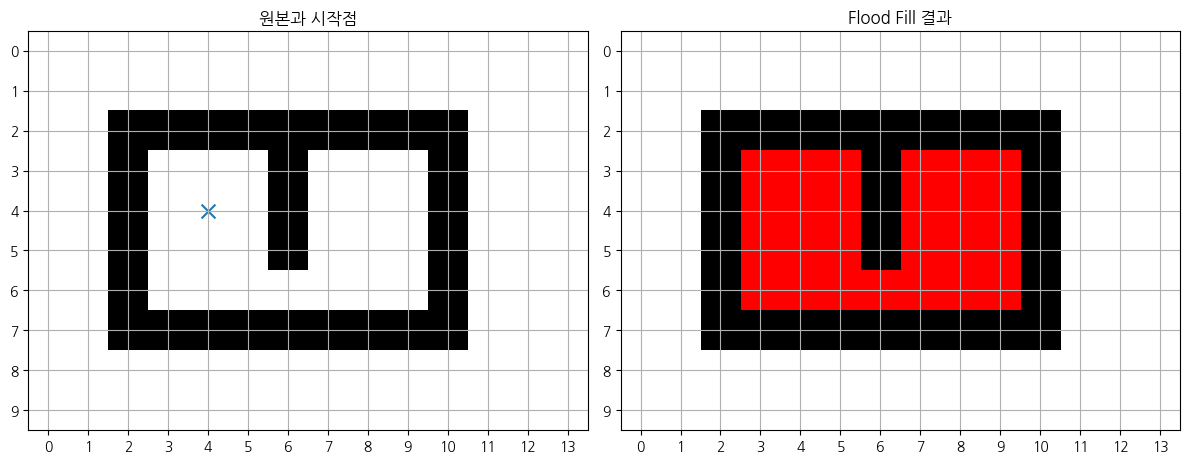

In [6]:
## --------------------------------------------------
## 원본과 시작점 그리고 채운 결과 시각화
## --------------------------------------------------
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.scatter(seed_point[0], seed_point[1], marker="x", s=100)
plt.title("원본과 시작점")
plt.xticks(range(image.shape[1]))
plt.yticks(range(image.shape[0]))
plt.grid()
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(filled_image, cv2.COLOR_BGR2RGB))
plt.title("Flood Fill 결과")
plt.xticks(range(image.shape[1]))
plt.yticks(range(image.shape[0]))
plt.grid()
plt.tight_layout()
plt.show()

- [3] 색상 허용 오차를 적용한 Flood Fill
    - 유사 픽셀 여부 결정
        * 현재 픽셀 s(x,y)
        * 이웃 픽셀 s(x',y')
        * s(x', y') - loDiff <= s(x,y) < s(s', y') + upDiff

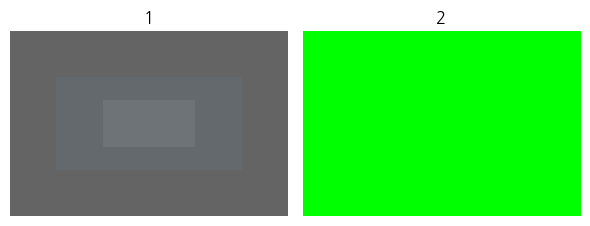

In [ ]:
# 실습 이미지 데이터 생성
gradient_image = np.zeros((8, 12, 3), dtype=np.uint8)

# 비슷한 회색 색상값 채우기
gradient_image[:,:] = [100, 100, 100]
gradient_image[2:6, 2:10] = [110, 105, 100]
gradient_image[3:5, 4:8] = [120, 115, 110]

# 마스크 생성
result = gradient_image.copy()
mask = np.zeros((result.shape[0] + 2, result.shape[1] + 2), dtype=np.uint8)

cv2.floodFill(result, mask, seedPoint=(5,4),newVal=(0, 255, 0), 
              loDiff=(15,15,15), upDiff=(15,15,15), flags=8)

# 시각화 출력
grad_rgb = cv2.cvtColor(gradient_image, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
printPlots(1,2, [1,2], [grad_rgb, result_rgb])

## 핵심 정리
Flood Fill은 시작점과 연결된 영역을 채웁니다.

- 활용 예:
    - 배경 채우기
    - 객체 내부 채우기
    - 구멍 채우기
    - 특정 영역 마스크 생성
